# Include the student-info block at the top (Name, ID, Section, GitHub, Kaggle, Dataset, Source), all 8 parts with a short interpretation under every table/plot, and the final checklist.
Name: Saba Noor

ID: 023-24-0278

Section: H

Github: https://github.com/SABANOOR1

Kaggle: https://www.kaggle.com/sabajaffar

Dataset: clean_churn.csv

Source: Dataset derived from lab 2.


In [2]:
# Task 1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining. 
import pandas as pd
df=pd.read_csv("clean_churn.csv")
df.dtypes
print(df.info())
print(df.duplicated())
print(df.shape)
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  Monthl

# Task 2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business? 

In this lab, we are trying to predict which customer features have the greatest impact on customer churn. This matters to the business because identifying these factors can help improve services and create better offers to retain customers and reduce churn.


In [8]:
# Task 3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present. 
y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [17]:
# Task 4: Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping). 
import pandas as pd
df=pd.read_csv("clean_churn.csv")
categorical_cols= X.select_dtypes(include=["str"]).columns
print(categorical_cols)
X=X.astype({col: int for col in X.select_dtypes(include="bool").columns})
X=pd.get_dummies(X,columns=categorical_cols,drop_first=True)
print(X.dtypes)
print("X shape:", X.shape)

Index([], dtype='str')
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int

In [16]:
# Task 5: Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping). 
print(X.duplicated())
print(X.isnull().sum().sum())
print(X.dtypes)

0       False
1       False
2       False
3       False
4       False
        ...  
7005    False
7006    False
7007    False
7008    False
7009    False
Length: 7010, dtype: bool
0
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet servi

In [20]:
# Task 6: Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2? 
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=y)

In [22]:
# Task 7: Report the shape of X_train, X_test, y_train, and y_test.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape:", Y_test.shape)

X_train shape: (5608, 30)
X_test shape: (1402, 30)
y_train shape: (5608,)
y_test shape: (1402,)


In [23]:
# Task 8 Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets. 
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)
Y_train_pred=dt_model.predict(X_train)
Y_test_pred=dt_model.predict(X_test)

In [25]:
# Task 9: What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?
print("Tree depth: ", dt_model.get_depth())


Tree depth:  24


# Explanation:
The tree grew to a depth of 24. This is somewhat surprising because the default decision tree can grow quite deep without pruning. A deep tree may fit the training data extremely well but can also overfit, which is something we can check by comparing the training and test performance.

In [43]:
# Task 10: 10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table. 
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
import pandas as pd

accuracy=accuracy_score(Y_test,Y_test_pred)
precision=precision_score(Y_test,Y_test_pred)
recall=recall_score(Y_test,Y_test_pred)
f1=f1_score(Y_test, Y_test_pred)

results=pd.DataFrame({
    "Matric":["Accuracy","Precision","Recall","F1"],
    "Score":[accuracy,precision,recall,f1]
})

print(results)

      Matric     Score
0   Accuracy  0.726819
1  Precision  0.483607
2     Recall  0.477089
3         F1  0.480326


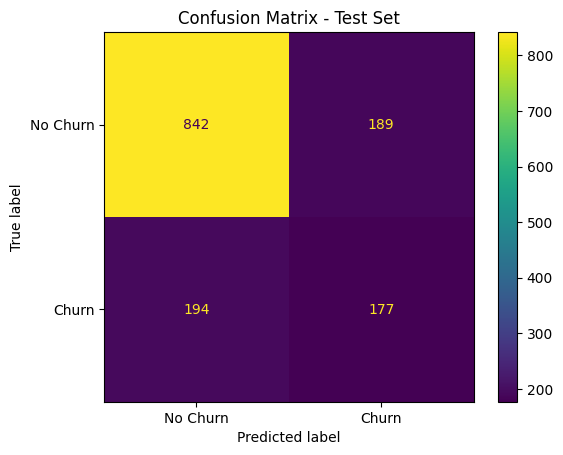

In [35]:
# Task 11: Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how 
many did it miss? 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm=confusion_matrix(Y_test,Y_test_pred)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# Task 12: Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

I would trust recall and F1-score more than accuracy for this problem. Recall is important because it tells us how many of the actual churners the model successfully identifies. Missing a customer who is likely to churn (a false negative) could be costly for the company. F1-score is also useful because it balances recall and precision. Accuracy can be misleading with imbalanced classes because a model can achieve high accuracy simply by predicting the majority class most of the time.

In [46]:
# Task 13: Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
from sklearn.metrics import accuracy_score

train_accuracy=accuracy_score(Y_train,Y_train_pred)
test_accuracy=accuracy_score(Y_test,Y_test_pred)

print("Training Accuracy:",train_accuracy)
print("Test Accuracy",test_accuracy)
print("Difference:",train_accuracy-test_accuracy)

Training Accuracy: 0.9980385164051355
Test Accuracy 0.7268188302425107
Difference: 0.2712196861626248


# Explanation
There is a large gap between the training and test accuracy. The training accuracy is much higher than the test accuracy, which suggests that the baseline decision tree is overfitting. It has learned the training data very closely but does not generalize as well to unseen data.

In [54]:
# Task 14: Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table. 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model2=DecisionTreeClassifier(max_depth=2,random_state=42)
model2.fit(X_train,Y_train)

Y_train_pred2=model2.predict(X_train)
Y_test_pred2=model2.predict(X_test)

train_accuracy2=accuracy_score(Y_train,Y_train_pred2)
test_accuracy2=accuracy_score(Y_test,Y_test_pred2)
print("Depth=2")
print("Training Accuracy:",train_accuracy2)
print("Test Accuracy",test_accuracy2)
print("Difference:",train_accuracy2-test_accuracy2)
print("--------------------------------------------")

model3=DecisionTreeClassifier(max_depth=5,random_state=42)
model3.fit(X_train,Y_train)

Y_train_pred3=model3.predict(X_train)
Y_test_pred3=model3.predict(X_test)

train_accuracy3=accuracy_score(Y_train,Y_train_pred3)
test_accuracy3=accuracy_score(Y_test,Y_test_pred3)
print("Depth=5")
print("Training Accuracy:",train_accuracy3)
print("Test Accuracy",test_accuracy3)
print("Difference:",train_accuracy3-test_accuracy3)
print("--------------------------------------------")

model4=DecisionTreeClassifier(max_depth=8,random_state=42)
model4.fit(X_train,Y_train)

Y_train_pred4=model4.predict(X_train)
Y_test_pred4=model4.predict(X_test)

train_accuracy4=accuracy_score(Y_train,Y_train_pred4)
test_accuracy4=accuracy_score(Y_test,Y_test_pred4)
print("Depth=8")
print("Training Accuracy:",train_accuracy4)
print("Test Accuracy",test_accuracy4)
print("Difference:",train_accuracy4-test_accuracy4)
print("--------------------------------------------")

model5=DecisionTreeClassifier(max_depth=11,random_state=42)
model5.fit(X_train,Y_train)

Y_train_pred5=model5.predict(X_train)
Y_test_pred5=model5.predict(X_test)

train_accuracy5=accuracy_score(Y_train,Y_train_pred5)
test_accuracy5=accuracy_score(Y_test,Y_test_pred5)
print("Depth=11")
print("Training Accuracy:",train_accuracy5)
print("Test Accuracy",test_accuracy5)
print("Difference:",train_accuracy5-test_accuracy5)
print("--------------------------------------------")


Depth=2
Training Accuracy: 0.7915477888730386
Test Accuracy 0.7860199714693296
Difference: 0.005527817403709001
--------------------------------------------
Depth=5
Training Accuracy: 0.7999286733238231
Test Accuracy 0.782453637660485
Difference: 0.01747503566333808
--------------------------------------------
Depth=8
Training Accuracy: 0.8352353780313837
Test Accuracy 0.7931526390870185
Difference: 0.042082738944365206
--------------------------------------------
Depth=11
Training Accuracy: 0.8942582025677603
Test Accuracy 0.7653352353780314
Difference: 0.12892296718972895
--------------------------------------------


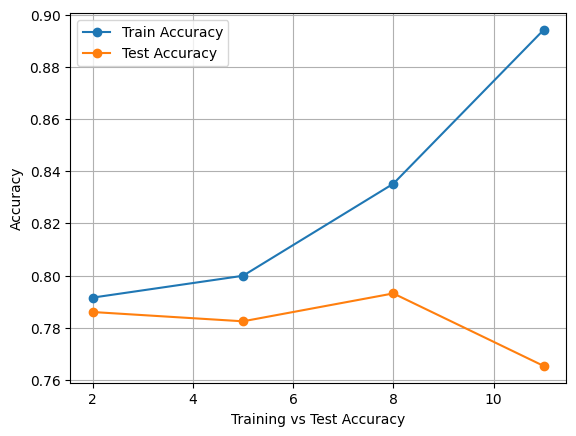

In [60]:
# Taks 15: Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this. 
import matplotlib.pyplot as plt

depths=[2,5,8,11]

train_accuracies=[
    train_accuracy2,
    train_accuracy3,
    train_accuracy4,
    train_accuracy5,
]
test_accuracies=[
    test_accuracy2,
    test_accuracy3,
    test_accuracy4,
    test_accuracy5,
]

plt.plot(
    depths,train_accuracies,marker="o",label="Train Accuracy"
)

plt.plot(
    depths,test_accuracies,marker="o",label="Test Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.xlabel("Training vs Test Accuracy")
plt.legend()
plt.grid()
plt.show()

# Explanation: 
The model starts to overfit at roughly the depth where training accuracy continues to increase while test accuracy stops improving or begins to decrease. This is shown by the growing gap between the training and test accuracy curves. A large gap indicates that the tree is learning the training data too closely and is not generalizing as well to unseen data.

# Task 16: Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy. 

I would select max_depth = 5 as the best model because it provides a good test accuracy while keeping the gap between training and test accuracy reasonably small. Deeper trees improve training accuracy but do not improve test performance significantly, which suggests that they are beginning to overfit.

In [61]:
# Task 17: Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
import pandas as pd

model3=DecisionTreeClassifier(max_depth=5,random_state=42)
model3.fit(X_train,Y_train)

Y_train_pred3=model3.predict(X_train)
Y_test_pred3=model3.predict(X_test)

train_accuracy3=accuracy_score(Y_train,Y_train_pred3)
test_accuracy3=accuracy_score(Y_test,Y_test_pred3)
print("Depth=5")
print("Training Accuracy:",train_accuracy3)
print("Test Accuracy",test_accuracy3)
print("Difference:",train_accuracy3-test_accuracy3)
print("--------------------------------------------")

accuracy=accuracy_score(Y_test,Y_test_pred3)
precision=precision_score(Y_test,Y_test_pred3)
recall=recall_score(Y_test,Y_test_pred3)
f1=f1_score(Y_test, Y_test_pred3)

results=pd.DataFrame({
    "Matric":["Accuracy","Precision","Recall","F1"],
    "Score":[accuracy,precision,recall,f1]
})

print(results)




Depth=5
Training Accuracy: 0.7999286733238231
Test Accuracy 0.782453637660485
Difference: 0.01747503566333808
--------------------------------------------
      Matric     Score
0   Accuracy  0.782454
1  Precision  0.622222
2     Recall  0.452830
3         F1  0.524181


In [64]:
# Task 18: Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

entropy_model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train,Y_train)

Y_train_Prediction=entropy_model.predict(X_train)
Y_test_Prediction=entropy_model.predict(X_test)

train_accuracy_entropy=accuracy_score(Y_train,Y_train_Prediction)
test_accuracy_entropy=accuracy_score(Y_test,Y_test_Prediction)

print("Criterion = Entropy")
print("Training Accuracy:", train_accuracy_entropy)
print("Test Accuracy:", test_accuracy_entropy)
print("Difference:", train_accuracy_entropy - test_accuracy_entropy)
print("--------------------------------------------")

accuracy=accuracy_score(Y_test,Y_test_Prediction)
precision=precision_score(Y_test,Y_test_Prediction)
recall=recall_score(Y_test,Y_test_Prediction)
f1=f1_score(Y_test,Y_test_Prediction)

results=pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1"],
    "Score":[accuracy,precision,recall,f1]
})
print(results)

Criterion = Entropy
Training Accuracy: 0.9980385164051355
Test Accuracy: 0.7339514978601998
Difference: 0.26408701854493577
--------------------------------------------
      Metric     Score
0   Accuracy  0.733951
1  Precision  0.497143
2     Recall  0.469003
3         F1  0.482663


                                  Feature  Importance
1                                  tenure    0.384707
10            InternetService_Fiber optic    0.348728
25                      Contract_Two year    0.057762
3                            TotalCharges    0.051156
24                      Contract_One year    0.031803
12     OnlineSecurity_No internet service    0.024018
28         PaymentMethod_Electronic check    0.022539
2                          MonthlyCharges    0.021926
11                     InternetService_No    0.015794
9                       MultipleLines_Yes    0.012584
0                           SeniorCitizen    0.009513
8          MultipleLines_No phone service    0.007795
19                        TechSupport_Yes    0.007180
27  PaymentMethod_Credit card (automatic)    0.002772
5                             Partner_Yes    0.001723
6                          Dependents_Yes    0.000000
7                        PhoneService_Yes    0.000000
4                           

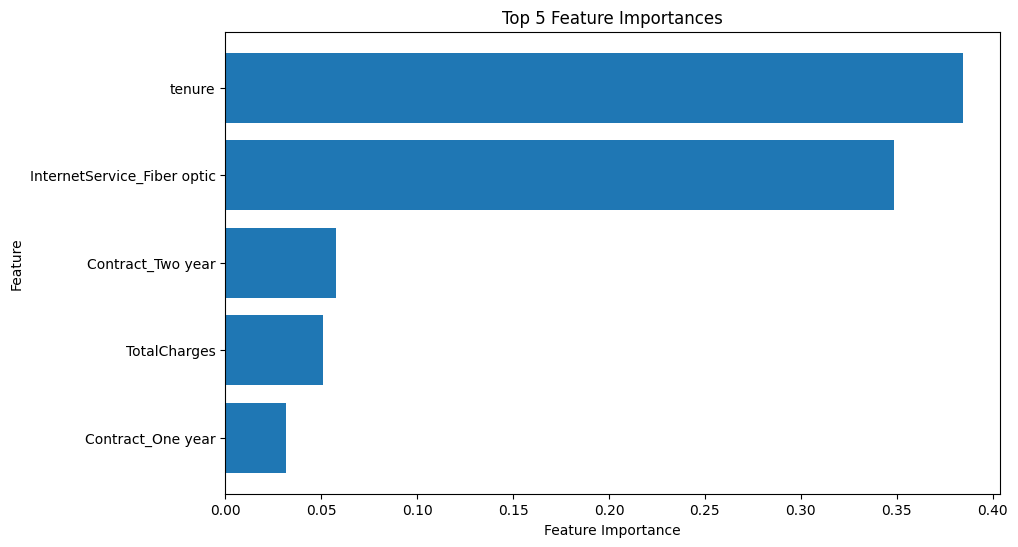

In [66]:
# Task 19: Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most? 
import pandas as pd
import matplotlib.pyplot as plt

feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":model3.feature_importances_
})
feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance)

top_features = feature_importance.head(5)
print(top_features)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

# Task 20: In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?
The most important features identified by the decision tree generally agree with the patterns observed in Lab 2 EDA. In particular, features such as tenure, MonthlyCharges, and contract-related variables showed noticeable relationships with customer churn in the EDA, and they also appeared among the most important features in the model. This suggests that the model is capturing patterns that were already visible during exploratory analysis.

# Task 21: Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
I selected the Decision Tree model with a maximum depth of 5 because it provided a good balance between training and test performance while reducing overfitting. The model achieved good accuracy, precision, recall, and F1-score on the test set, showing that it can reasonably predict customer churn. Compared with an unrestricted tree, limiting the depth helps the model generalize better to unseen customers. However, the model still has limitations, including possible overfitting and sensitivity to the particular training data. Also, feature importance shows which features the tree uses most, but it does not prove that those features actually cause customer churn.


# Task 22:  What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

If I had more time, I would try a different algorithm such as Random Forest or XGBoost to see if it can predict churn better than a single decision tree. I would also do some more feature engineering, such as creating useful groups from tenure or monthly charges. Since the dataset has more customers who do not churn, I would also try handling the class imbalance using techniques like class weights or resampling. Finally, I would compare the models using recall and F1-score, not just accuracy, because correctly identifying customers who are likely to churn is especially important.

In [68]:
#Task 23: Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — write your own entropy and information gain functions. Print the gain values for each attribute at every split.  
import pandas as pd
import math

data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Rainy",
        "Overcast", "Sunny", "Sunny", "Rainy", "Sunny", "Overcast",
        "Overcast", "Rainy"
    ],

    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool", "Cool",
        "Cool", "Mild", "Cool", "Mild", "Mild", "Mild",
        "Hot", "Mild"
    ],

    "Humidity": [
        "High", "High", "High", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "Normal", "Normal", "High",
        "Normal", "High"
    ],

    "Windy": [
        "Weak", "Strong", "Weak", "Weak", "Weak", "Strong",
        "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
        "Weak", "Strong"
    ],

    "PlayTennis": [
        "No", "No", "Yes", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes", "Yes", "Yes",
        "Yes", "No"
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

def entropy(target):

    counts = target.value_counts()
    total = len(target)

    result = 0

    for count in counts:
        probability = count / total
        result -= probability * math.log2(probability)

    return result

def information_gain(df, attribute):

    total_entropy = entropy(df["PlayTennis"])

    weighted_entropy = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        probability = len(subset) / len(df)

        weighted_entropy += probability * entropy(
            subset["PlayTennis"]
        )

    gain = total_entropy - weighted_entropy

    return gain

def id3(df, attributes, level=0):

    if len(df["PlayTennis"].unique()) == 1:
        return df["PlayTennis"].iloc[0]

    if len(attributes) == 0:
        return df["PlayTennis"].mode()[0]

    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(df, attribute)

    print("\n" + "    " * level + "Information Gain:")

    for attribute in attributes:
        print(
            "    " * level +
            attribute + " = " +
            str(round(gains[attribute], 4))
        )

    best_attribute = max(gains, key=gains.get)

    print(
        "    " * level +
        "Selected Attribute: " +
        best_attribute
    )

    tree = {best_attribute: {}}

    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best_attribute
    ]

    for value in df[best_attribute].unique():

        subset = df[df[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            level + 1
        )

    return tree

attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Windy"
]

tree = id3(df, attributes)

print("\nFinal Decision Tree:")
print(tree)

Dataset:
     Outlook Temperature Humidity   Windy PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3      Rainy        Mild     High    Weak        Yes
4      Rainy        Cool   Normal    Weak        Yes
5      Rainy        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9      Rainy        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13     Rainy        Mild     High  Strong         No

Information Gain:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Windy = 0.0481
Selected Attribute: Outlook

    Information Gain:
    Temperature = 0.571
    Humidity = 0.971
    Windy 